In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from algorithms.matrix_free_rsvd import get_approximate_W

from scipy.stats import sem, t

from utils.colors import C3
from utils.utils import progress_bar
from utils.solvers import fast_proj_solver_cg
from utils.problem_setup import TestProblemsSetup
from utils.metrics import error_auc_iou, error_movers
from utils.exact_forward_operator import ExactForwardOperator
from utils.projected_tikhonov import get_epsilon, discrepancy_principle
from utils.exact_forward_operator import ExactForwardOperator, fast_get_weights

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15

In [ ]:
def experiment(
        problem: dict,
        p_list: list,
        repeat: int = 10,
        k: int = 100,
        seed = None
    ) -> pd.DataFrame:
    rsvd, V_h = problem['rsvd'], problem['V_h']

    # Compute SVD
    exact = ExactForwardOperator(V_h)
    _, Sf, _ = np.linalg.svd(exact.K, full_matrices=False)
    Sf = Sf[:k]  # numpy array of size k

    step = 1
    tot_steps = repeat * len(p_list)
    results = []
    for r in range(repeat):
        for p in p_list:
            progress_bar(step, tot_steps)
            step += 1

            _, Sr, _ = rsvd.mf_rsvd(k=k, p=p, seed=seed + r + p)
            ratio = Sr / Sf

            for i, val in enumerate(ratio):
                results.append({'r': r, 'p': p, 'i': i, 'ratio': val})

    return pd.DataFrame(results)


In [81]:
setup = TestProblemsSetup(n=32)
problems = setup.get_test_problems()
ratio = {}

p_list = [0, 5, 10]
df = experiment(
    problem=problems['I'],
    p_list=p_list,
    repeat=30,
    seed=SEED
)


[##############################] 90/90


In [93]:
p_list = [0, 5, 10]
df2 = experiment(
    problem=problems['III'],
    p_list=p_list,
    repeat=30,
    seed=SEED
)


[##############################] 90/90


In [99]:
# Compute mean and 95% CI for each (p, i)
def mean_and_ci(values):
    n = len(values)
    m = np.mean(values)
    se = sem(values)
    h = se * t.ppf((1 + 0.95) / 2., n-1)
    return pd.Series({'mean': m, 'ci': h})

summary = df.groupby(['p','i']).ratio.apply(mean_and_ci).unstack()
summary = summary.reset_index()

summary2 = df2.groupby(['p','i']).ratio.apply(mean_and_ci).unstack()
summary2 = summary2.reset_index()

summaries = {'I': summary, 'III': summary2}

In [115]:
def save_plot(fig_name: str) -> None:
    if fig_name is not None:
        path = Path(f"../../figures/{fig_name}.png")
        if not path.exists():
            plt.savefig(path, dpi=300, bbox_inches="tight")
        else:
            print(path, 'already exists')

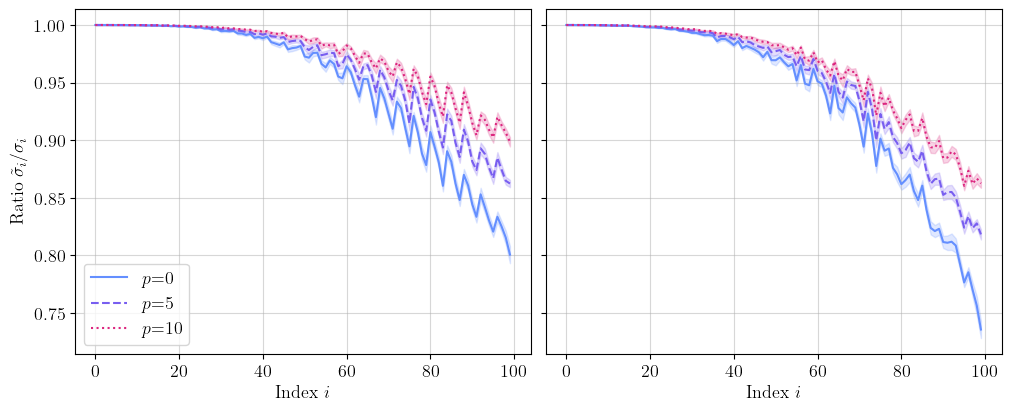

In [127]:
from utils.colors import M, MS

LS = ['-', '--', ':']

fig, axes = plt.subplots(
    1, 2, figsize=(10, 4), constrained_layout=True,
    sharey=True 
)

s = 4
for pid, ax in zip(['I', 'III'], axes):
    
    sm = summaries[pid]
    for idx, p in enumerate(p_list):
        data = sm[summary['p'] == p]
        ax.plot(data['i'], data['mean'], c=C3[idx], ls=LS[idx], label=f'$p$={p}')
        #ax.plot(data['i'][::s], data['mean'][::s], M[idx], c=C3[idx])
        ax.fill_between(
            data['i'],
            data['mean'] - data['ci'],
            data['mean'] + data['ci'],
            color=C3[idx],
            alpha=0.2
        )

    ax.grid(True, alpha=0.5)
    ax.set_xlabel('Index $i$')

axes[0].set_ylabel('Ratio $\\tilde \sigma_i / \sigma_i$')
axes[0].legend()

save_plot(fig_name='singular_values_comp')
plt.show()